Date       0
 Volume    0
 Open      0
 High      0
 Low       0
 Close     0
dtype: int64
['Date', ' Volume', ' Open', ' High', ' Low', ' Close']
['Date', 'Volume', 'Open', 'High', 'Low', 'Close']
           Date     Volume      Open      High       Low     Close
0    2012-03-19  224435817   $85.48    $85.97    $84.15    $85.87 
1    2012-03-20  203497481   $85.64    $86.70    $83.14    $86.57 
2    2012-03-21  160447118   $86.11    $87.09    $85.92    $86.07 
3    2012-03-22  155867437   $85.40    $86.36    $85.08    $85.62 
4    2012-03-23  107403062   $85.78    $85.97    $84.91    $85.15 
...         ...        ...       ...       ...       ...       ...
1995 2020-02-24   55548830  $297.26   $304.18   $289.23   $298.18 
1996 2020-02-25   57668360  $300.95   $302.53   $286.13   $288.08 
1997 2020-02-26   49678430  $286.53   $297.88   $286.50   $292.65 
1998 2020-02-27   80151380  $281.10      $286   $272.96   $273.52 
1999 2020-02-28  106721200  $257.26   $278.41   $256.37   $273.36

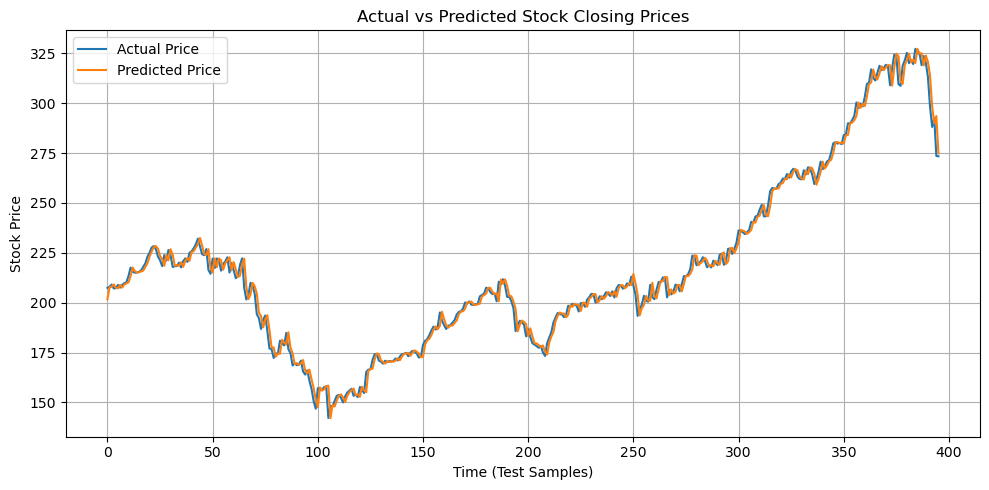

In [5]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import joblib   # ✅ added for saving model

df=pd.read_csv('Stock_trend.csv')
df.head()

#checking null values
print(df.isnull().sum())
print(list(df.columns))

# Remove leading/trailing spaces from all column names
df.columns = df.columns.str.strip()
print(list(df.columns))

#As our data has no null values so we dont have to do data preprocessing ,,lets move to next step
#NO NEED OF OUTLIER DETECTION
"""Why Outlier Detection is NOT Required Here
🔹 1️⃣ Stock price “outliers” are usually REAL events
In stock data:
Sudden price jumps,Market crashes,High-volume spikes
These are not errors — they are actual market behavior.
Example:COVID crash,Earnings announcement spike
If you remove these:You remove important learning signals and Model becomes unrealistic"""

#------------DATA PREPROCESSING------------------
#Converting date (text) to datetime object so pyhton understands it and perform operations of sorting,calculation etc!!
df['Date'] = pd.to_datetime(df['Date'])

#checking if propely converted or not
df.dtypes

#Sort data chronologically
df = df.sort_values('Date')
df = df.reset_index(drop=True)
print(df)

# List of price columns to clean
price_cols = ['Open', 'High', 'Low', 'Close']

# Clean each column
for col in price_cols:
    # Remove $ if present, strip spaces, convert to float
   df[col] = df[col].replace(r'[\$,]', '', regex=True).astype(float)
   df[col] = df[col].astype(float)

#-------------FEATURE ENGINEERING----------------
# 1️⃣ Short-term moving average (captures recent trend)
df['MA_5'] = df['Close'].rolling(window=5).mean()

# 2️⃣ Long-term moving average (captures overall trend)
df['MA_20'] = df['Close'].rolling(window=20).mean()

# 3️⃣ Daily return (measures day-to-day price change)
df['Daily_Return'] = df['Close'].pct_change()

# 4️⃣ Price momentum over 5 days (measures trend strength)
df['Momentum_5'] = df['Close'] - df['Close'].shift(5)

# 5️⃣ Volatility (measures daily price fluctuation)
df['Volatility'] = df['High'] - df['Low']

# 6️⃣ Moving average crossover (identifies trend direction/change)
df['MA_Crossover'] = df['MA_5'] - df['MA_20']

# 7️⃣ Remove rows with NaN values created by rolling and shifting
df = df.dropna().reset_index(drop=True)

# Create target column (next day's closing price)
df['Target'] = df['Close'].shift(-1)   # shift(-1) assigns tomorrow’s price as today’s label

# Remove rows with NaN values created by shifting
df = df.dropna()   # last row has no future price, so we drop it

# Verify target column alignment
print(df[['Close', 'Target']].tail())   # check today's price vs tomorrow's price

#--------Training Testing Part-----------
# Separate features (X) and target (y)
X = df.drop(['Target', 'Date'], axis=1)   # remove target & date from inputs
y = df['Target']                          # future closing price

# Define split index (80% train, 20% test)
split_index = int(len(df) * 0.8)

# Time-based split (NO shuffling)
X_train = X.iloc[:split_index]   # past data for training
X_test  = X.iloc[split_index:]   # future data for testing

y_train = y.iloc[:split_index]
y_test  = y.iloc[split_index:]

#printing the dimensions (rows, columns) of your training and testing data.
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)
#--------Model Trainingg---------
# Initialize the Linear Regression model
lr_model = LinearRegression()   # baseline regression model

# Train the model using training data
lr_model.fit(X_train, y_train)   # learns relationship between features and future price

# Predict future prices on test set
y_pred = lr_model.predict(X_test)   # model predicts based on X_test features

# Quick check: compare first 5 predictions with actual values
print("Predicted:", y_pred[:5])
print("Actual   :", y_test.iloc[:5].values)

#----------Model Evaluation-----------------
# Mean Absolute Error: average absolute difference
mae = mean_absolute_error(y_test, y_pred)

# Mean Squared Error: average squared difference
mse = mean_squared_error(y_test, y_pred)

# Root Mean Squared Error: square root of MSE
rmse = np.sqrt(mse)

# R² Score: how much variance is explained by the model
r2 = r2_score(y_test, y_pred)

# Print evaluation metrics
print("MAE  :", mae)
print("MSE  :", mse)
print("RMSE :", rmse)
print("R²   :", r2)
#---Saviing feature column
feature_columns = X.columns.tolist()
joblib.dump(feature_columns, "features.pkl")

#-------------SAVE MODEL-----------------
joblib.dump(lr_model, "stockTrend_LinearRegression.pkl")   # ✅ save trained model
joblib.dump(X.columns.tolist(), "model_features.pkl")  # ✅ save feature names

#print("✅ Model and feature list saved successfully")
import matplotlib.pyplot as plt

# Create index for test data (time order)
test_index = range(len(y_test))

plt.figure(figsize=(10, 5))
plt.plot(test_index, y_test.values, label="Actual Price")
plt.plot(test_index, y_pred, label="Predicted Price")

plt.title("Actual vs Predicted Stock Closing Prices")
plt.xlabel("Time (Test Samples)")
plt.ylabel("Stock Price")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()



In [3]:
import pandas as pd
df=pd.read_csv('Stock_Trend.csv')
#------------DATA PREPROCESSING------------------
#Converting date (text) to datetime object so pyhton understands it and perform operations of sorting,calculation etc!!
df['Date'] = pd.to_datetime(df['Date'])

#checking if propely converted or not
df.dtypes

#Sort data chronologically
df = df.sort_values('Date')
df = df.reset_index(drop=True)
print(df)


           Date     Volume      Open      High       Low     Close
0    2012-03-19  224435817   $85.48    $85.97    $84.15    $85.87 
1    2012-03-20  203497481   $85.64    $86.70    $83.14    $86.57 
2    2012-03-21  160447118   $86.11    $87.09    $85.92    $86.07 
3    2012-03-22  155867437   $85.40    $86.36    $85.08    $85.62 
4    2012-03-23  107403062   $85.78    $85.97    $84.91    $85.15 
...         ...        ...       ...       ...       ...       ...
1995 2020-02-24   55548830  $297.26   $304.18   $289.23   $298.18 
1996 2020-02-25   57668360  $300.95   $302.53   $286.13   $288.08 
1997 2020-02-26   49678430  $286.53   $297.88   $286.50   $292.65 
1998 2020-02-27   80151380  $281.10      $286   $272.96   $273.52 
1999 2020-02-28  106721200  $257.26   $278.41   $256.37   $273.36 

[2000 rows x 6 columns]
